In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC\Downloads\archive\Extended_Employee_Performance_and_Productivity_Data.csv")

print(df.shape)
df.head()


(100000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [ ]:

if "Hire_Date" in df.columns:
    df["Hire_Date"] = pd.to_datetime(df["Hire_Date"], errors="coerce")

if "Education_Level" in df.columns:
    edu_order = ["High School","Bachelor","Master","PhD"]
    df["Education_Level"] = pd.Categorical(df["Education_Level"], categories=edu_order, ordered=True)

if "Remote_Work_Frequency" in df.columns:
    df["Remote_Work_Frequency"] = (
        df["Remote_Work_Frequency"]
        .astype(str).str.replace("%","", regex=False).str.strip()
    )
    df["Remote_Work_Frequency"] = pd.to_numeric(df["Remote_Work_Frequency"], errors="coerce")

attr_types = {}
for c in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[c]):
        typ = "datetime"
    elif pd.api.types.is_numeric_dtype(df[c]):
        typ = "numeric"
    elif pd.api.types.is_categorical_dtype(df[c]):
        typ = "categorical (ordered)" if getattr(df[c], "ordered", False) else "categorical"
    else:
        typ = "categorical"
    attr_types[c] = typ

attr_types_df = pd.DataFrame({"Attribute": list(attr_types.keys()), "Type": list(attr_types.values())})
print("Number of samples:", len(df))
print("Number of attributes:", df.shape[1])
attr_types_df


Number of samples: 100000
Number of attributes: 20


C:\Users\eren_\AppData\Local\Temp\ipykernel_31264\2843825913.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[c]):


,Attribute,Type
0,Employee_ID,numeric
1,Department,categorical
2,Gender,categorical
3,Age,numeric
4,Job_Title,categorical
5,Hire_Date,datetime
6,Years_At_Company,numeric
7,Education_Level,categorical
8,Performance_Score,numeric
9,Monthly_Salary,numeric


In [ ]:

missing_df = df.isna().sum().reset_index()
missing_df.columns = ["Attribute","Missing_Count"]
missing_df["Missing_%"] = (missing_df["Missing_Count"]/len(df)*100).round(2)
missing_df.sort_values("Missing_Count", ascending=False)


,Attribute,Missing_Count,Missing_%
0,Employee_ID,0,0.0
1,Department,0,0.0
2,Gender,0,0.0
3,Age,0,0.0
4,Job_Title,0,0.0
5,Hire_Date,0,0.0
6,Years_At_Company,0,0.0
7,Education_Level,0,0.0
8,Performance_Score,0,0.0
9,Monthly_Salary,0,0.0


In [ ]:

ordinal_cols = []
for cand in ["Performance_Score","Employee_Satisfaction_Score","Remote_Work_Frequency","Education_Level"]:
    if cand in df.columns:
        ordinal_cols.append(cand)

numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ordinal_cols]

for rid in ["Employee_ID"]:
    if rid in numeric_cols:
        numeric_cols.remove(rid)

categorical_cols = [c for c in df.columns 
                    if (df[c].dtype == object or pd.api.types.is_categorical_dtype(df[c])) 
                    and c not in ordinal_cols]
print("Numeric:", numeric_cols)
print("Ordinal:", ordinal_cols)
print("Categorical:", categorical_cols)


NameError: name 'np' is not defined

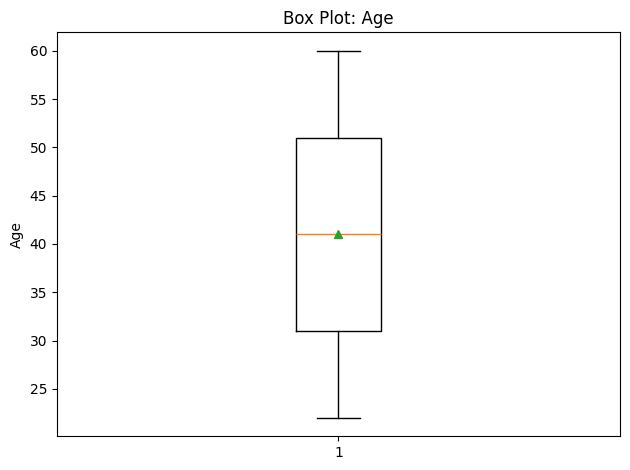

Saved -> hr_eda_figs\box_Age.png


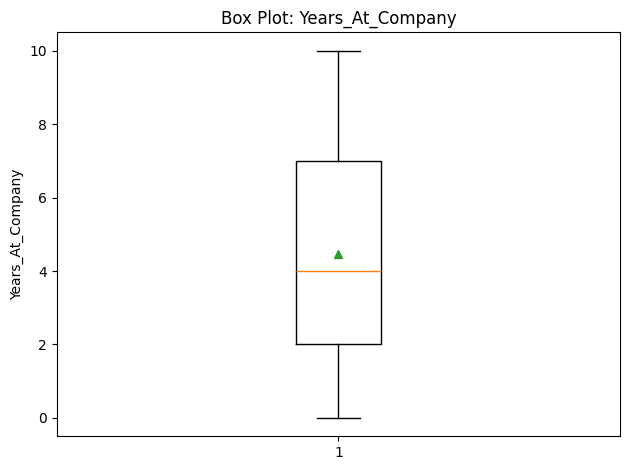

Saved -> hr_eda_figs\box_Years_At_Company.png


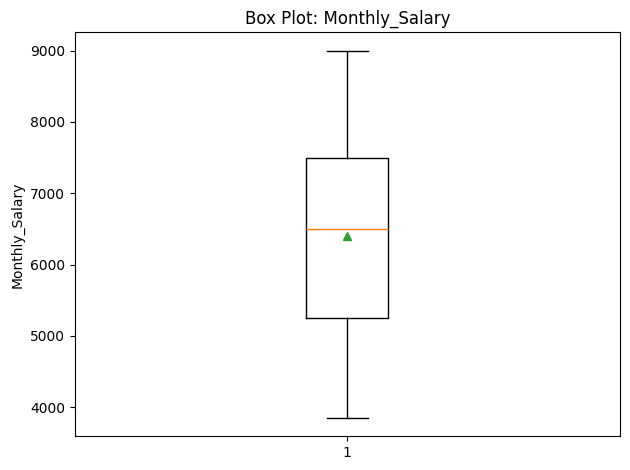

Saved -> hr_eda_figs\box_Monthly_Salary.png


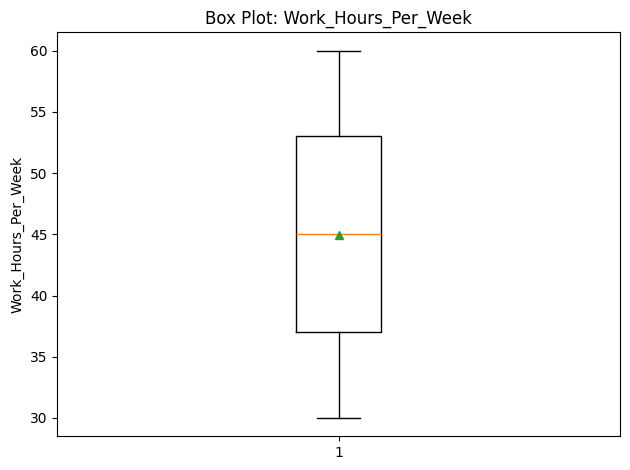

Saved -> hr_eda_figs\box_Work_Hours_Per_Week.png


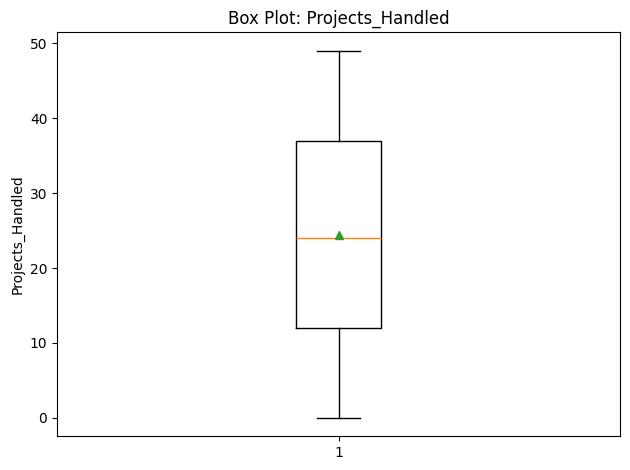

Saved -> hr_eda_figs\box_Projects_Handled.png


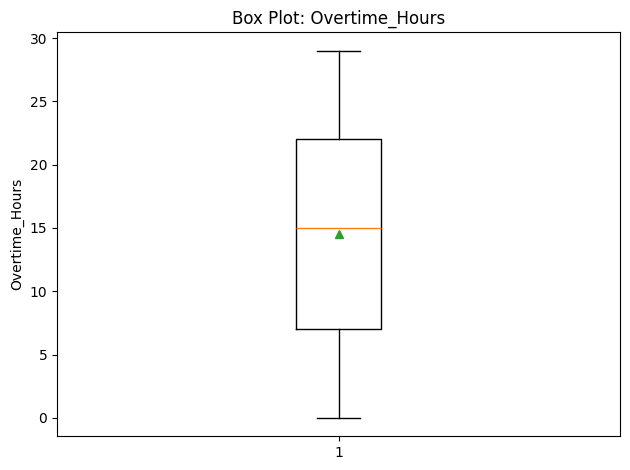

Saved -> hr_eda_figs\box_Overtime_Hours.png


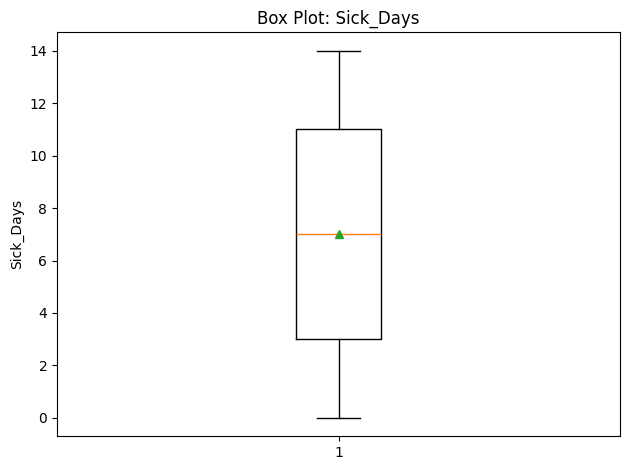

Saved -> hr_eda_figs\box_Sick_Days.png


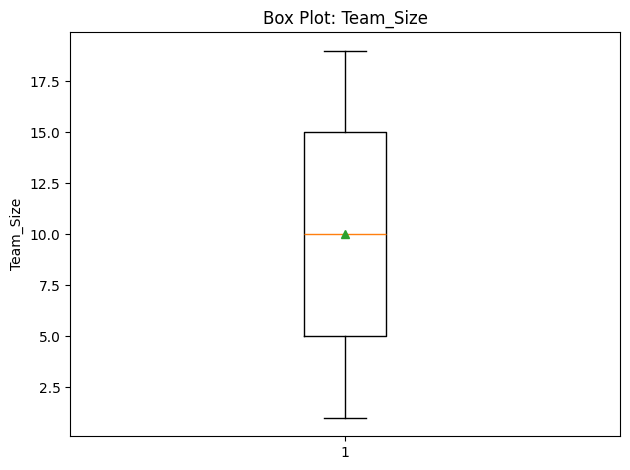

Saved -> hr_eda_figs\box_Team_Size.png


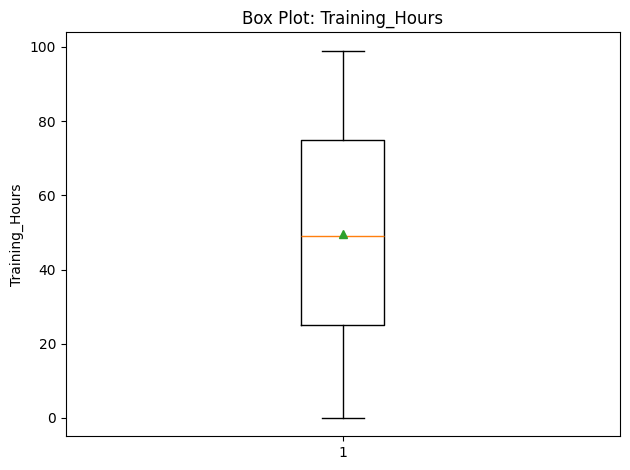

Saved -> hr_eda_figs\box_Training_Hours.png


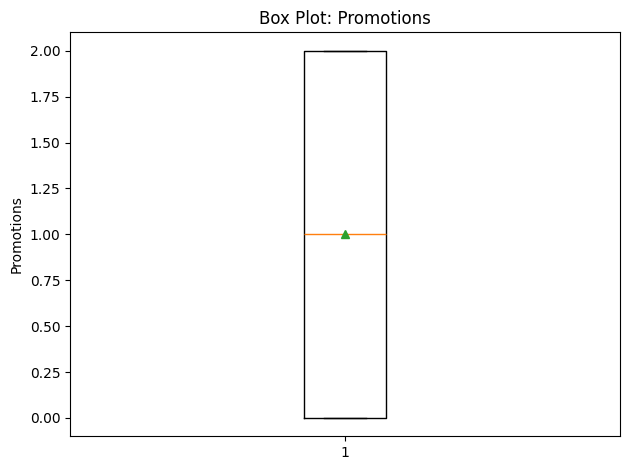

Saved -> hr_eda_figs\box_Promotions.png


In [ ]:

for c in numeric_cols:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=True, whis=1.5, showmeans=True)
    plt.title(f"Box Plot: {c}")
    plt.ylabel(c)
    savefig_show(f"box_{c}.png")


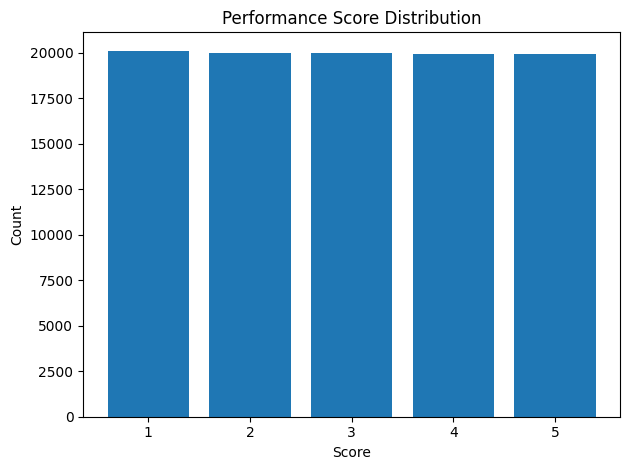

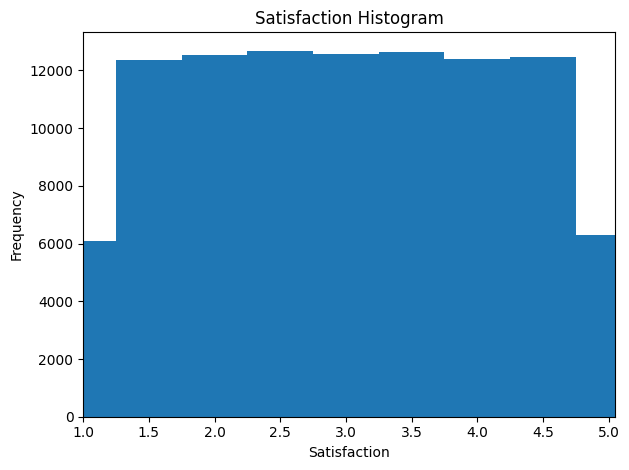

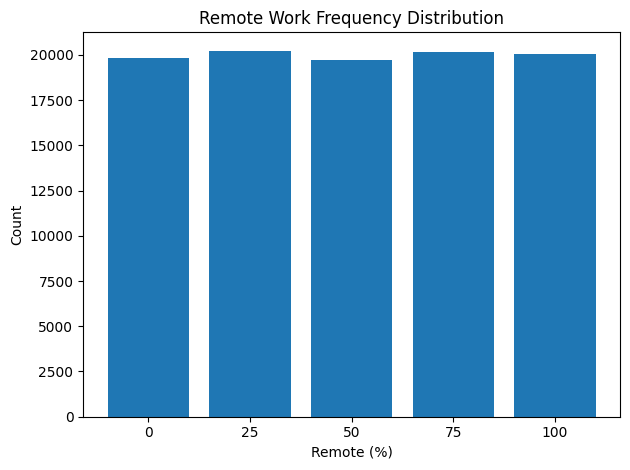